# Sesion 1: Fundamentos - Avanzado

Objetivo

Carga, limpieza, descriptivos y visualización.

## Fundamentos


In [ ]:
# ===== 1. LIBRERÍAS =====

import pandas as pd              # Manejo de datos estructurados (DataFrames)
import numpy as np               # Cálculo numérico y operaciones vectorizadas
import matplotlib.pyplot as plt  # Visualización básica (gráficos)
import seaborn as sns            # Visualización avanzada basada en matplotlib
import statsmodels.api as sm     # Modelos estadísticos (regresión, inferencia)
import kagglehub                 # Descarga de datasets directamente desde Kaggle

from sklearn.model_selection import train_test_split  # División de datos en entrenamiento y prueba
from sklearn.ensemble import RandomForestRegressor    # Modelo de Machine Learning tipo ensemble (bosques aleatorios)
from sklearn.metrics import r2_score, mean_absolute_error  # Métricas de evaluación para regresión
from sklearn.preprocessing import StandardScaler      # Estandarización de variables (media=0, var=1)

np.random.seed(42)  # Fijar semilla para reproducibilidad de resultados

In [ ]:
# ===== 2. DATOS SINTÉTICOS =====

n = 200  # Número de observaciones (filas) que tendrá el dataset

df = pd.DataFrame({  # Creación de un DataFrame con variables simuladas
    "edad": np.random.randint(18, 65, n),
    # Genera edades aleatorias entre 18 y 64 años (distribución uniforme)

    "genero": np.random.choice(["Hombre", "Mujer"], n),
    # Asigna aleatoriamente género (variable categórica)

    "educacion": np.random.randint(6, 20, n),
    # Años de educación (por ejemplo: primaria a posgrado)

    "ingresos": np.random.normal(2500, 800, n)
    # Genera ingresos con distribución normal (media=2500, desviación estándar=800)
})

df["ingresos"] = df["ingresos"].clip(500, 10000)
# Limita los ingresos a un rango razonable (mín=500, máx=10000) para evitar valores extremos

df.head()
# Muestra las primeras 5 filas del dataset para inspección rápida

,edad,genero,educacion,ingresos
0,56,Mujer,18,3768.813453
1,46,Hombre,19,1509.747601
2,32,Mujer,10,4206.426700
3,60,Hombre,11,938.329760
4,25,Hombre,8,2378.571924


In [ ]:
# ===== 3. EXPLORACIÓN =====
df.shape
# Devuelve la dimensión del dataset: (filas, columnas)
# Útil para verificar tamaño de la muestra y número de variables

(200, 4)

In [ ]:
df.info()
# Muestra información estructural:
# - tipos de datos (int, float, object)
# - valores no nulos (detección de missing values)
# - uso de memoria

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   edad       200 non-null    int64  
 1   genero     200 non-null    object 
 2   educacion  200 non-null    int64  
 3   ingresos   200 non-null    float64
dtypes: float64(1), int64(2), object(1)
memory usage: 6.4+ KB


In [ ]:
df.describe()
# Estadísticas descriptivas de variables numéricas:
# - media, desviación estándar, min, max
# - percentiles (25%, 50%, 75%)
# Sirve para detectar outliers o distribuciones anómalas

,edad,educacion,ingresos
count,200.000000,200.000000,200.000000
mean,41.570000,12.545000,2544.227946
std,13.715527,4.045964,776.843931
min,18.000000,6.000000,658.463068
25%,30.000000,9.000000,2020.496457
50%,42.000000,12.000000,2513.438497
75%,54.000000,16.000000,3046.382075
max,64.000000,19.000000,4963.104647


In [ ]:
df["genero"].value_counts()
# Cuenta la frecuencia de cada categoría en la variable 'genero'
# Permite ver si hay desbalance en la variable categórica

,count
genero,
Mujer,108
Hombre,92


In [ ]:
# ===== 4. LIMPIEZA =====

df.isnull().sum()
# Cuenta valores nulos por columna
# Permite identificar si hay datos faltantes y en qué variables

,0
edad,0
genero,0
educacion,0
ingresos,0


In [ ]:
df = df.drop_duplicates()
# Elimina filas duplicadas del dataset
# Importante para evitar sesgos o sobre-representación de ciertos datos

In [ ]:
# eliminar valores extremos
df = df[df["ingresos"] < 9000]
# Filtra registros con ingresos menores a 9000
# Se usa como criterio simple para remover outliers (valores atípicos altos)

In [ ]:
# ===== 5. ESTADÍSTICAS =====

# MEDIA (promedio aritmético)
mean_ing = df["ingresos"].mean()
# Calcula la media de los ingresos
# Sensible a valores extremos (outliers), por lo que puede sesgarse

# MEDIANA (percentil 50)
median_ing = df["ingresos"].median()
# Valor central de la distribución
# Robusto frente a outliers → mejor medida de tendencia central en datos sesgados

# DESVIACIÓN ESTÁNDAR
std_ing = df["ingresos"].std()
# Mide la dispersión de los ingresos respecto a la media
# Alta desviación → mayor variabilidad económica

# ASIMETRÍA (SKEWNESS)
skew_ing = df["ingresos"].skew()
# Indica si la distribución está sesgada:
# > 0 → cola hacia la derecha (ingresos altos extremos)
# < 0 → cola hacia la izquierda

# IMPRESIÓN DE RESULTADOS
print(f"Media ingresos: {mean_ing:.2f}")
print(f"Mediana ingresos: {median_ing:.2f}")
print(f"Desviación estándar: {std_ing:.2f}")
print(f"Asimetría (skewness): {skew_ing:.2f}")

Media ingresos: 2544.23
Mediana ingresos: 2513.44
Desviación estándar: 776.84
Asimetría (skewness): 0.14


Ingreso promedio por género:
genero
Hombre    2558.412813
Mujer     2532.144541
Name: ingresos, dtype: float64

Desviación estándar por género:
genero
Hombre    757.479921
Mujer     796.287714
Name: ingresos, dtype: float64

Cantidad de observaciones por género:
genero
Mujer     108
Hombre     92
Name: count, dtype: int64


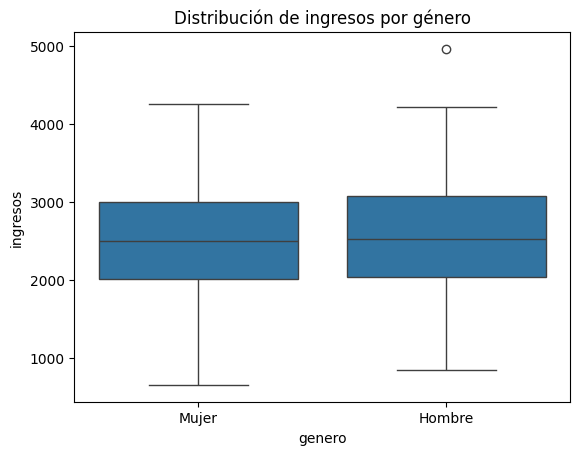

In [ ]:
# ===== 6. COMPARACIÓN =====

# Agrupamos por género y calculamos la media de ingresos
# Esto permite observar diferencias promedio entre grupos (estadística descriptiva por subpoblaciones)
media_por_genero = df.groupby("genero")["ingresos"].mean()

print("Ingreso promedio por género:")
print(media_por_genero)


# También es clave ver la dispersión, no solo la media
# std = desviación estándar → mide variabilidad intra-grupo
std_por_genero = df.groupby("genero")["ingresos"].std()

print("\nDesviación estándar por género:")
print(std_por_genero)


# Contar número de observaciones por grupo
# Importante para evaluar representatividad (tamaño muestral)
conteo = df["genero"].value_counts()

print("\nCantidad de observaciones por género:")
print(conteo)


# ===== VISUALIZACIÓN =====

# Boxplot: muestra mediana, cuartiles y posibles outliers
# Es más robusto que la media para comparar distribuciones
sns.boxplot(x="genero", y="ingresos", data=df)

plt.title("Distribución de ingresos por género")
plt.show()

In [ ]:
# ===== EJERCICIO =====
# 1. Graficar edad
# 2. Comparar ingresos por educación
# 3. Identificar si hay desigualdad

## NIVEL BÁSICO (ANÁLISIS + EXPLICACIÓN)

### 1. Setup y dataset

In [ ]:
# dataset sintético más realista
n = 300

df = pd.DataFrame({
    "edad": np.random.randint(18, 65, n),
    "educacion": np.random.randint(5, 18, n),
    "genero": np.random.choice(["Hombre", "Mujer"], n)
})

# ingresos con estructura social
df["ingresos"] = (
    400 +
    df["educacion"] * 180 +
    df["edad"] * 10 +
    np.random.normal(0, 300, n) -
    (df["genero"] == "Mujer") * 350
)

df.head()

,edad,educacion,genero,ingresos
0,52,11,Mujer,2438.902989
1,32,8,Hombre,1909.932304
2,42,10,Hombre,2413.137904
3,54,9,Mujer,2358.486655
4,45,12,Hombre,3135.475766


### 2. Exploración rápida

In [ ]:
df.describe()
df["genero"].value_counts()

,count
genero,
Hombre,163
Mujer,137


### 3. Distribuciones (lectura de datos)

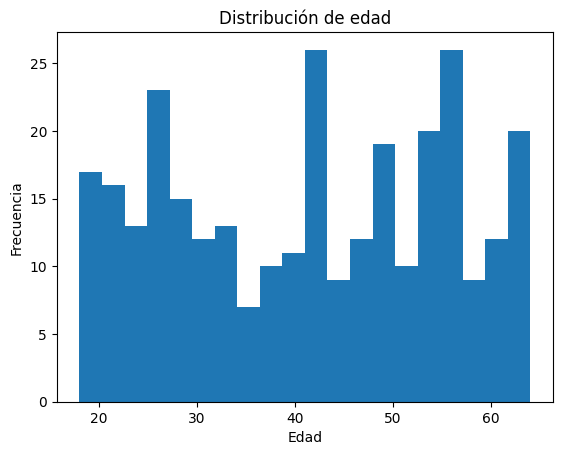

In [ ]:
plt.hist(df["edad"], bins=20)
plt.title("Distribución de edad")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.show()

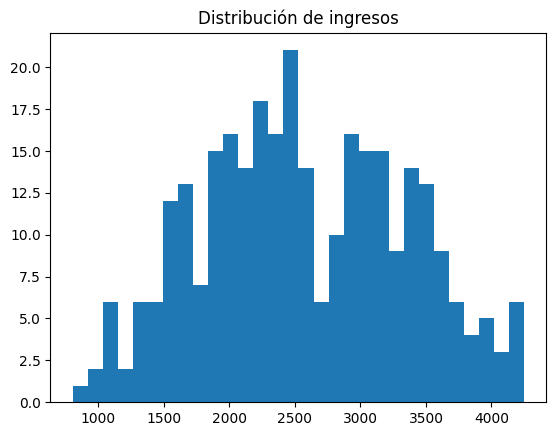

In [ ]:
plt.hist(df["ingresos"], bins=30)
plt.title("Distribución de ingresos")
plt.show()

### 4. Comparaciones clave

#### Ingresos por educación

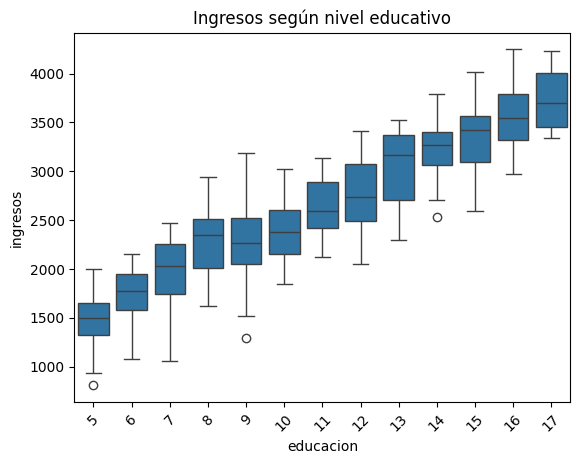

In [ ]:
sns.boxplot(data=df, x="educacion", y="ingresos")
plt.xticks(rotation=45)
plt.title("Ingresos según nivel educativo")
plt.show()

#### Ingresos por género

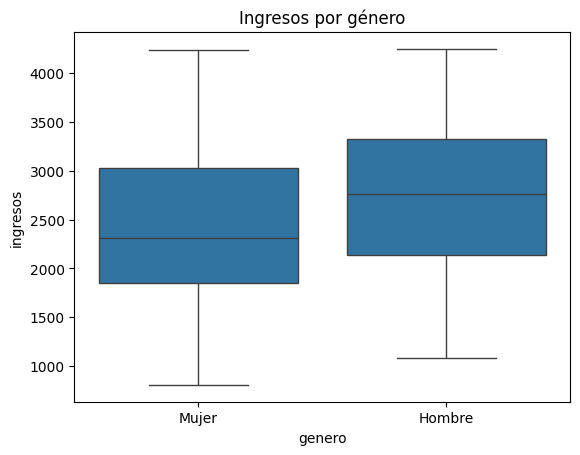

In [ ]:
sns.boxplot(data=df, x="genero", y="ingresos")
plt.title("Ingresos por género")
plt.show()

### 5. Relación entre variables

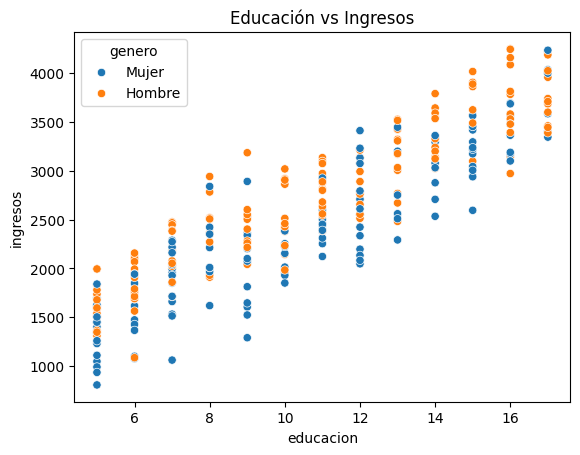

In [ ]:
sns.scatterplot(data=df, x="educacion", y="ingresos", hue="genero")
plt.title("Educación vs Ingresos")
plt.show()

### 6. Correlación

In [ ]:
df[["edad", "educacion", "ingresos"]].corr()

,edad,educacion,ingresos
edad,1.000000,0.095403,0.253075
educacion,0.095403,1.000000,0.891024
ingresos,0.253075,0.891024,1.000000


### 7. Interpretación guiada

Interpretación

1. ¿Qué variable parece influir más en los ingresos?
2. ¿La relación entre educación e ingresos es clara?
3. ¿Existen diferencias entre hombres y mujeres?
4. ¿Estas diferencias son pequeñas o sistemáticas?

Conclusión:
- La educación tiene una relación positiva con ingresos
- La edad también influye, pero menos
- Se observa una posible brecha de género


## NIVEL BÁSICO 2 (ANÁLISIS + CONTROL)

### 1. Setup y datos

In [ ]:
n = 300

df = pd.DataFrame({
    "edad": np.random.randint(18, 65, n),
    "educacion": np.random.randint(5, 18, n),
    "genero": np.random.choice(["Hombre", "Mujer"], n)
})

# ingresos con múltiples factores
df["ingresos"] = (
    500 +
    df["educacion"] * 200 +
    df["edad"] * 8 +
    np.random.normal(0, 250, n) -
    (df["genero"] == "Mujer") * 400
)

df.head()

,edad,educacion,genero,ingresos
0,59,6,Mujer,1970.859563
1,59,9,Mujer,2574.238225
2,53,8,Hombre,2280.490944
3,37,17,Hombre,4310.874327
4,21,7,Mujer,2063.648491


### 2. Problema central

In [ ]:
# promedio general
df.groupby("genero")["ingresos"].mean()

,ingresos
genero,
Hombre,3087.737144
Mujer,2546.878846


Pregunta:

¿Existe desigualdad?

### 3. Problema más profundo

In [ ]:
# ¿y si controlamos por educación?
df.groupby(["genero", "educacion"])["ingresos"].mean().unstack()

educacion,5,6,7,8,9,10,11,12,13,14,15,16,17
genero,,,,,,,,,,,,,
Hombre,1844.854698,1913.848736,2306.084199,2524.617880,2612.002981,2692.936261,2980.975167,3206.510291,3413.318339,3683.857154,3907.140043,4001.360916,4409.282686
Mujer,1349.263741,1689.641949,1826.402307,1876.620963,2119.064316,2471.111393,2569.340789,2836.572133,2962.485640,3215.242157,3522.035950,3720.217705,3665.026507


### 4. Visualización con control

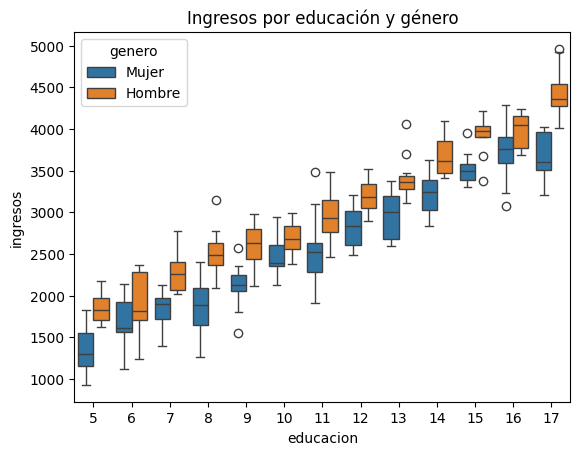

In [ ]:
sns.boxplot(data=df, x="educacion", y="ingresos", hue="genero")
plt.title("Ingresos por educación y género")
plt.show()

### 5. Interpretación guiada

In [ ]:
# diferencia promedio dentro de cada nivel educativo
tabla = df.groupby(["educacion", "genero"])["ingresos"].mean().unstack()

tabla["brecha"] = tabla["Hombre"] - tabla["Mujer"]
tabla.head()

genero,Hombre,Mujer,brecha
educacion,,,
5,1844.854698,1349.263741,495.590956
6,1913.848736,1689.641949,224.206787
7,2306.084199,1826.402307,479.681893
8,2524.617880,1876.620963,647.996916
9,2612.002981,2119.064316,492.938666


### 6. Visualizar brecha

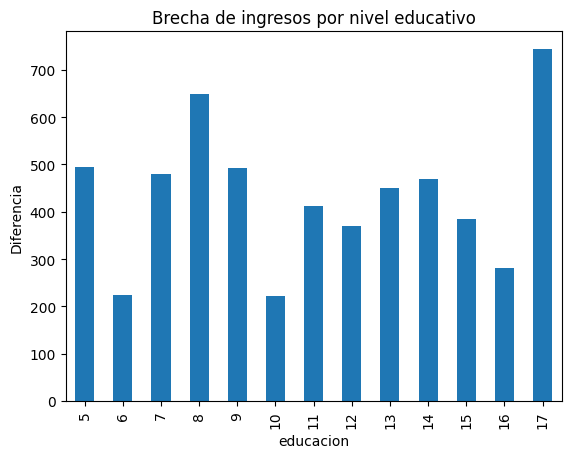

In [ ]:
tabla["brecha"].plot(kind="bar")
plt.title("Brecha de ingresos por nivel educativo")
plt.ylabel("Diferencia")
plt.show()

### 7. Primera idea de modelo

In [ ]:
df["mujer"] = (df["genero"] == "Mujer").astype(int)

X = df[["educacion", "edad", "mujer"]]
X = sm.add_constant(X)

y = df["ingresos"]

modelo = sm.OLS(y, X).fit()

print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:               ingresos   R-squared:                       0.905
Model:                            OLS   Adj. R-squared:                  0.905
Method:                 Least Squares   F-statistic:                     945.1
Date:                Tue, 14 Apr 2026   Prob (F-statistic):          3.16e-151
Time:                        05:59:27   Log-Likelihood:                -2092.2
No. Observations:                 300   AIC:                             4192.
Df Residuals:                     296   BIC:                             4207.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        521.0045     67.602      7.707      0.0

### 8. Interpretación guiada

Interpretación

- ¿El coeficiente de "mujer" es negativo?
→ indica una posible brecha de género

- ¿Educación tiene efecto positivo?
→ más años → más ingresos

- ¿Edad influye?
→ experiencia acumulada

Conclusión:
Ahora no solo vemos diferencias,
sino que controlamos múltiples factores al mismo tiempo.

## NIVEL INTERMEDIO

### Cargar datos

In [ ]:
# Download latest version
path = kagglehub.dataset_download("madhurpant/world-economic-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'world-economic-data' dataset.
Path to dataset files: /kaggle/input/world-economic-data


In [ ]:
# =========================================
# 1. CARGA DE DATOS
# =========================================

corruption = pd.read_csv(f"{path}/corruption.csv")
cost = pd.read_csv(f"{path}/cost_of_living.csv")
unemployment = pd.read_csv(f"{path}/unemployment.csv")

print("Corruption:")
display(corruption.head())

print("Cost of living:")
display(cost.head())

print("Unemployment:")
display(unemployment.head())

Corruption:


,country,annual_income,corruption_index
0,Denmark,68110,12
1,Finland,53660,12
2,New Zealand,45340,12
3,Norway,84090,15
4,Singapore,64010,15


Cost of living:


,country,cost_index,monthly_income,purchasing_power_index
0,Bermuda,157.6,9712,105.0
1,Switzerland,142.4,7530,90.1
2,Cayman Islands,137.9,5281,65.2
3,Israel,130.2,4130,54.1
4,Iceland,128.0,5368,71.5


Unemployment:


,country,unemployment_rate
0,Marshall Islands,36.0
1,South Africa,33.6
2,Kiribati,30.6
3,Kosovo,30.5
4,American Samoa,29.8


In [ ]:
# =========================================
# 2. LIMPIEZA Y MERGE
# =========================================

# Unimos datasets por índice (todos tienen países en mismo orden)
df = pd.concat([corruption, cost, unemployment], axis=1)

# Eliminamos columnas duplicadas si existen
df = df.loc[:, ~df.columns.duplicated()]

df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110 entries, 0 to 109
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   country                 110 non-null    object 
 1   annual_income           110 non-null    int64  
 2   corruption_index        110 non-null    int64  
 3   cost_index              107 non-null    float64
 4   monthly_income          107 non-null    float64
 5   purchasing_power_index  107 non-null    float64
 6   unemployment_rate       64 non-null     float64
dtypes: float64(4), int64(2), object(1)
memory usage: 6.1+ KB


,annual_income,corruption_index,cost_index,monthly_income,purchasing_power_index,unemployment_rate
count,110.000000,110.000000,107.000000,107.000000,107.000000,64.000000
mean,17195.727273,59.200000,62.555140,1826.532710,38.150467,7.823437
std,23741.147397,22.170234,33.747716,2100.275033,30.588024,8.806685
min,240.000000,12.000000,22.800000,87.000000,3.400000,0.100000
25%,1470.000000,41.750000,36.400000,295.000000,14.050000,2.700000
50%,4130.000000,69.000000,48.900000,782.000000,25.800000,5.000000
75%,25410.000000,75.000000,84.550000,3130.000000,59.100000,8.250000
max,90360.000000,89.000000,157.600000,9712.000000,121.100000,36.000000


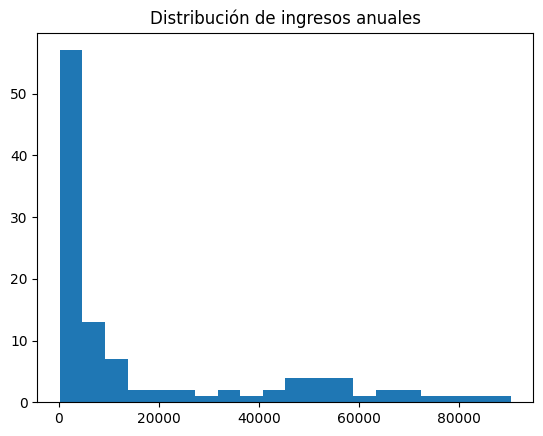

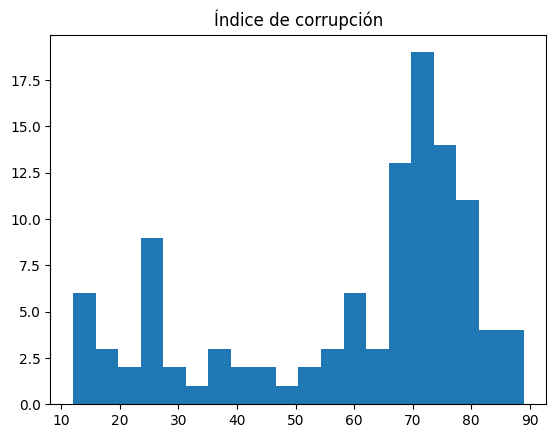

In [ ]:
# =========================================
# 3. EXPLORACIÓN VISUAL
# =========================================

# Distribución de ingresos
plt.hist(df["annual_income"], bins=20)
plt.title("Distribución de ingresos anuales")
plt.show()

# Distribución de corrupción
plt.hist(df["corruption_index"], bins=20)
plt.title("Índice de corrupción")
plt.show()

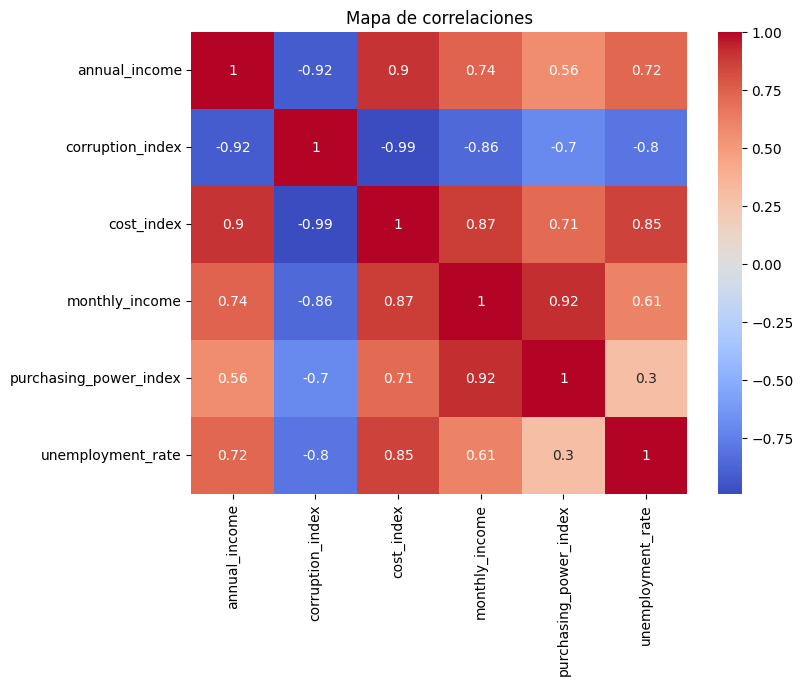

In [ ]:
# =========================================
# 4. RELACIONES (CORRELACIÓN)
# =========================================

corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Mapa de correlaciones")
plt.show()

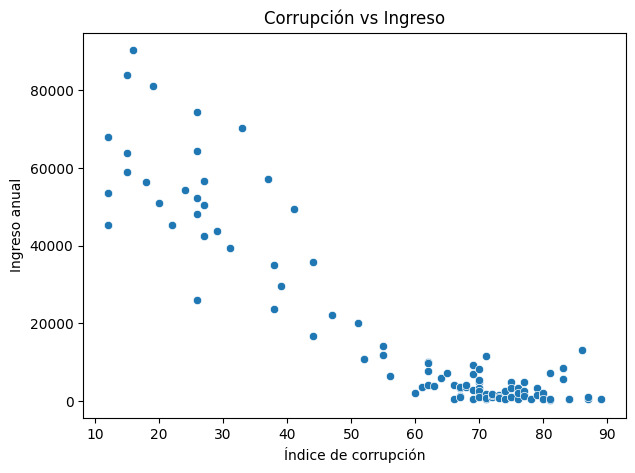

In [ ]:
# =========================================
# 5. ANÁLISIS CLAVE (DISPERSIÓN)
# =========================================

plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x="corruption_index", y="annual_income")

plt.title("Corrupción vs Ingreso")
plt.xlabel("Índice de corrupción")
plt.ylabel("Ingreso anual")

plt.show()

¿Relación negativa?
¿Países ricos → menos corrupción?

In [ ]:
# =========================================
# 6. REGRESIÓN SIMPLE
# =========================================

from scipy import stats

x = df["corruption_index"]
y = df["annual_income"]

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

print("Pendiente:", round(slope,2))
print("Intercepto:", round(intercept,2))
print("R²:", round(r_value**2,3))
print("p-valor:", round(p_value,4))

Pendiente: -981.62
Intercepto: 75307.68
R²: 0.84
p-valor: 0.0


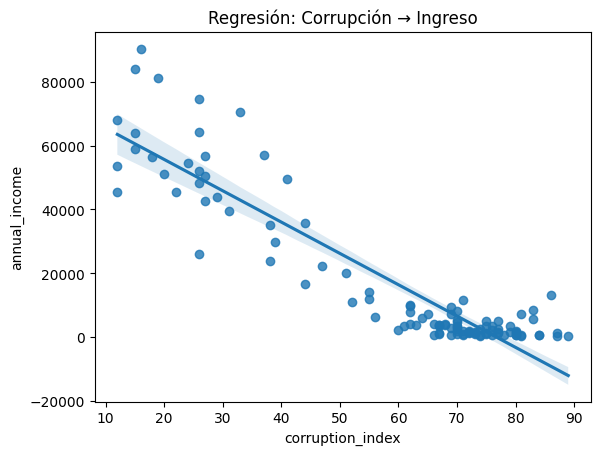

In [ ]:
# =========================================
# 7. VISUALIZACIÓN CON REGRESIÓN
# =========================================

sns.regplot(data=df, x="corruption_index", y="annual_income")

plt.title("Regresión: Corrupción → Ingreso")
plt.show()

In [ ]:
# =========================================
# 8. INTERPRETACIÓN (IMPORTANTE)
# =========================================

print("""
Interpretación:

- La pendiente indica cuánto cambia el ingreso
  cuando cambia la corrupción.

- R² indica cuánto explica el modelo.

- p-valor indica si la relación es significativa.

PERO:
- No implica causalidad
- Puede haber variables omitidas
""")


Interpretación:

- La pendiente indica cuánto cambia el ingreso
  cuando cambia la corrupción.

- R² indica cuánto explica el modelo.

- p-valor indica si la relación es significativa.

PERO:
- No implica causalidad
- Puede haber variables omitidas



In [ ]:
# =========================================
# 9. EJERCICIO (PARA ESTUDIANTES)
# =========================================

# 1. Analiza relación entre:
#    - costo de vida y poder adquisitivo

#sns.scatterplot(data=df, x="cost_index", y="purchasing_power")
#plt.show()

# 2. Calcula correlación
#print(df["cost_index"].corr(df["purchasing_power"]))

# 3. Pregunta:
# ¿Mayor costo implica menor poder adquisitivo?

## NOTEBOOK — NIVEL AVANZADO (DATA + ML + INTERPRETACIÓN)

¿Podemos predecir el nivel de ingresos de un país a partir de variables estructurales?

In [ ]:
# =========================================
# 1. CARGA DE DATOS
# =========================================

corruption = pd.read_csv(f"{path}/corruption.csv")
cost = pd.read_csv(f"{path}/cost_of_living.csv")
unemployment = pd.read_csv(f"{path}/unemployment.csv")

df = pd.concat([corruption, cost, unemployment], axis=1)
df = df.loc[:, ~df.columns.duplicated()]

df.head()

,country,annual_income,corruption_index,cost_index,monthly_income,purchasing_power_index,unemployment_rate
0,Denmark,68110,12,157.6,9712.0,105.0,36.0
1,Finland,53660,12,142.4,7530.0,90.1,33.6
2,New Zealand,45340,12,137.9,5281.0,65.2,30.6
3,Norway,84090,15,130.2,4130.0,54.1,30.5
4,Singapore,64010,15,128.0,5368.0,71.5,29.8


In [ ]:
# =========================================
# 2. DEFINICIÓN DEL PROBLEMA
# =========================================

# Variable objetivo (Y)
y = df["annual_income"]

# Variables predictoras (X)
X = df.drop(columns=["annual_income", "country"], errors="ignore")

X.head()

,corruption_index,cost_index,monthly_income,purchasing_power_index,unemployment_rate
0,12,157.6,9712.0,105.0,36.0
1,12,142.4,7530.0,90.1,33.6
2,12,137.9,5281.0,65.2,30.6
3,15,130.2,4130.0,54.1,30.5
4,15,128.0,5368.0,71.5,29.8


In [ ]:
# =========================================
# 3. TRAIN / TEST SPLIT
# =========================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (88, 5)
Test size: (22, 5)


In [ ]:
# =========================================
# 4. NORMALIZACIÓN
# =========================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# =========================================
# 5. MODELO (RANDOM FOREST)
# =========================================

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

model.fit(X_train_scaled, y_train)

RandomForestRegressor(max_depth=5, n_estimators=200, random_state=42)

In [ ]:
# =========================================
# 6. EVALUACIÓN
# =========================================

y_pred = model.predict(X_test_scaled)

print("R²:", round(r2_score(y_test, y_pred),3))
print("MAE:", round(mean_absolute_error(y_test, y_pred),2))

R²: 0.913
MAE: 4719.34


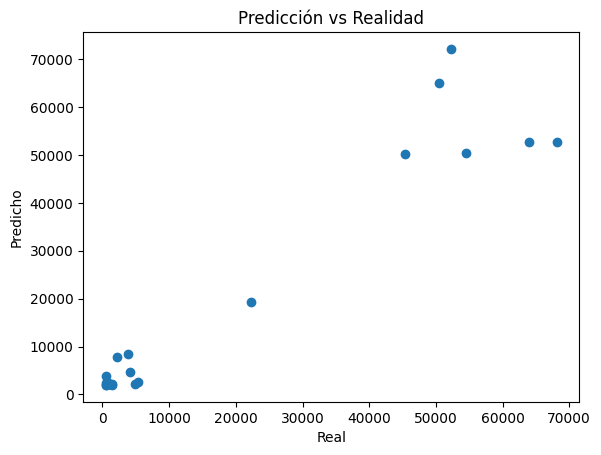

In [ ]:
# =========================================
# 7. VISUALIZACIÓN PRED vs REAL
# =========================================

plt.scatter(y_test, y_pred)
plt.xlabel("Real")
plt.ylabel("Predicho")
plt.title("Predicción vs Realidad")
plt.show()

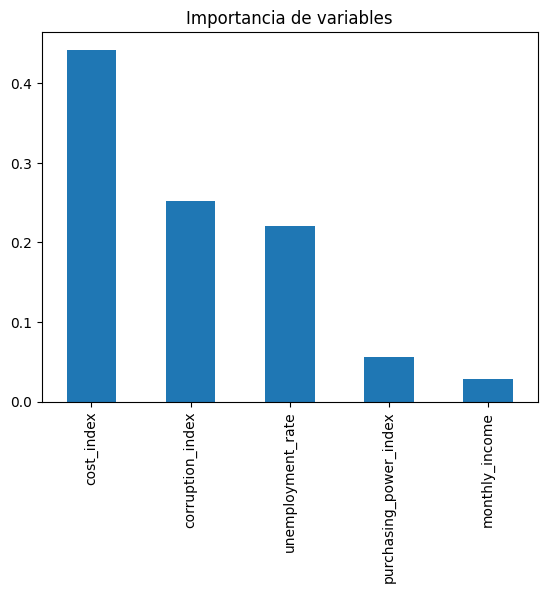

In [ ]:
# =========================================
# 8. IMPORTANCIA DE VARIABLES (CLAVE)
# =========================================

importances = pd.Series(model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

importances.plot(kind="bar")
plt.title("Importancia de variables")
plt.show()

In [ ]:
# =========================================
# 9. INTERPRETACIÓN (CRÍTICA)
# =========================================

print("""
Interpretación:

- El modelo aprende patrones no lineales
- Algunas variables pesan más que otras

PERO:

- Esto NO implica causalidad
- Puede haber variables omitidas
- Puede haber sesgos en los datos

Este modelo predice, no explica completamente
""")


Interpretación:

- El modelo aprende patrones no lineales
- Algunas variables pesan más que otras

PERO:

- Esto NO implica causalidad
- Puede haber variables omitidas
- Puede haber sesgos en los datos

Este modelo predice, no explica completamente



In [ ]:
# =========================================
# 10. CLASIFICACIÓN (BONUS AVANZADO)
# =========================================

# Convertimos ingreso en categorías
df["nivel_ingreso"] = pd.qcut(df["annual_income"], q=3, labels=["bajo","medio","alto"])

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

y_class = df["nivel_ingreso"]
X_class = X

X_train, X_test, y_train, y_test = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42
)

model_clf = RandomForestClassifier(n_estimators=200, random_state=42)
model_clf.fit(X_train, y_train)

pred = model_clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.8636363636363636


In [ ]:
# =========================================
# 11. EJERCICIO AVANZADO
# =========================================

# 1. Cambia el modelo por:
#    - LinearRegression
#    - DecisionTree

# 2. Compara resultados

# 3. Responde:
# ¿Qué modelo funciona mejor?
# ¿Por qué?

# 4. Pregunta crítica:
# ¿Este modelo sirve para política pública?